DSC550-T302<br>
Week 7 Assignment<br>
Jeremy Barton

## Demonstrationg Dimensionality Reduction and Feature Selection

Imports and preprocessing

In [1]:
import pandas as pd

### Part 1: PCA and Variance Threshold in a Linear Regression

#### 1) Import the housing data as a data frame and ensure that the data is loaded properly.

In [2]:
housing_df = pd.read_csv("data/housing/train.csv")

In [3]:
# ensure the data is here
housing_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


2) Drop the "Id" column and any features that are missing more than 40% of their values.

In [4]:
# using .drop()
housing_df = housing_df.drop(columns="Id")

In [5]:
ts = 0.4 # define the 40% treshold

# use .isnull().mean() to create a threshold
#   to add to a list
housing_df = housing_df.loc[:, housing_df.isnull().mean() <= ts]

3) For numerical columns, fill in any missing data with the median value.

In [6]:
# select particular dtyles with .select_dtypes()
num_col = housing_df.select_dtypes(include='number').columns

In [7]:
# .fillna() should take care of this
housing_df[num_col] = housing_df[num_col].fillna(housing_df[num_col].median())

4) For categorical columns, fill in any missing data with the most common value (mode).

In [8]:
# define categorical variables
cat_col = housing_df.select_dtypes(include='str').columns

# "number" can just be swapped for "object"
for col in cat_col: # for column in the categorical columns
    if housing_df[col].isnull().any(): # if any null valuses exist
        housing_df[col] = housing_df[col].fillna(housing_df[col].mode()[0])
        # fill them with the mode

In [9]:
# quick check on the dataframe
housing_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500


5) Convert the categorical columns to dummy variables.

In [10]:
housing_df = pd.get_dummies(housing_df, columns=cat_col, drop_first=True)
# dropfirst drops the first dummy per column

6) Split the data into a training and test set, where the SalePrice column is the target.

In [11]:
from sklearn.model_selection import train_test_split

# remove the target from the training ata
X = housing_df.drop(columns='SalePrice')
y = housing_df['SalePrice']

# create the train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 80% training, 20% testing and random_state = 42
#   makes it reproducable

7) Run a linear regression and report the R2-value and RMSE on the test set.

In [12]:
# import linear regression, r2 and rmse from sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [13]:
# report r2 and RMSE on the test set
print(f"R2:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):,.2f}")

R2:   0.6478
RMSE: 51,973.14


According to the R2 score, 64% of the variation in SalePrice can be explained by the linear relationship between SalePrice and the features in our dataset.

8) Fit and transform the training features with a PCA so that 90% of the variance is retained (see section 9.1 in the Machine Learning with Python Cookbook).

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [15]:
# standardize the feature matrix
scaler = StandardScaler()
features_train = scaler.fit_transform(X_train)

# create a PCA that will retain 90% of variance
pca = PCA(n_components=0.90, whiten=True)

# conduct PCA
features_pca_train = pca.fit_transform(features_train)

9) How many features are in the PCA-transformed matrix?

In [16]:
# show the differences
print("Original number of features:", features_train.shape[1])
print("Reduced number of features:", features_pca_train.shape[1])

Original number of features: 229
Reduced number of features: 127


PCA reduced the dataset by 102 features.

10) Transform but DO NOT fit the test features with the same PCA.

In [17]:
# scale the test features using the already-fit scaler
features_test = scaler.transform(X_test)

# apply PCA to the newly transformed features
features_pca_test = pca.transform(features_test)

11) Repeat step 7 with your PCA transformed data.

In [18]:
# rerun regression with PCA-transformed data
model_pca = LinearRegression()
model_pca.fit(features_pca_train, y_train)

y_pred_pca = model_pca.predict(features_pca_test)

print(f"R2:   {r2_score(y_test, y_pred_pca):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_pca):,.2f}")

R2:   0.8409
RMSE: 34,938.50


So after reducing dimensionality via feature extraction, the model accuracy had improved +10% to 84%. RSME is much lower (20K) as well.

12) Take your original training features (from step 6) and apply a min-max scaler to them.

In [19]:
from sklearn.preprocessing import MinMaxScaler

## using "_mm" as min max scaler
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)

# transform only on test
X_test_mm = scaler_mm.transform(X_test)

13) Find the min-max scaled features in your training set that have a variance above 0.1 (see Section 10.1 in the Machine Learning with Python Cookbook).

In [20]:
from sklearn.feature_selection import VarianceThreshold

# create thresholder
thresholder = VarianceThreshold(threshold=0.1)

# define high-variance feature matrix
features_hv = thresholder.fit_transform(X_train_mm)

14. Transform but DO NOT fit the test features with the same steps applied in steps 11 and 12.

In [21]:
# scale the test features using the already-fit min-max scaler
X_test_mm = scaler_mm.transform(X_test)

# apply thresholder to the newly scaled features
features_hv_test = thresholder.transform(X_test_mm)

15) Repeat step 7 with the high variance data.

In [22]:
model_hv = LinearRegression()
model_hv.fit(features_hv, y_train)
y_pred_hv = model_hv.predict(features_hv_test)

In [23]:
print(f"R2:   {r2_score(y_test, y_pred_hv):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_hv):,.2f}")

R2:   0.6481
RMSE: 51,952.01


16) Summarize your findings.

Throughout this ML pipeline, we tested three approaches to predicting SalePrice using linear regression. 

<b> The Baseline</b><br>
The baseline model (step 7) used all 229 raw features and achieved an R² of 0.6478 and RMSE of $51,973. This explains roughly 64% of the variance in SalePrice.

<b>PCA</b><br>
The PCA model (step 11) reduced the feature set from 229 down to 127 components while retaining 90% of the variance. This was the strongest performer, achieving an R² of 0.8409 and RMSE of $34,938, a 20-point improvement in R² and ~$17,000 reduction in error. PCA's ability to remove noise and multicollinearity while preserving the most important variance likely explains the significant jump in performance.

<b>MinMax Scaling</b><br>
The high variance model (step 15) used min-max scaling and a variance threshold of 0.1 to select features, resulting in 72 features. It achieved an R² of 0.6481 and RMSE of $51,952 - nearly identical to the baseline, suggesting that variance alone is not a strong signal for which features are most predictive of SalePrice.

### Part 2: Categorical Feature Selection

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2
from sklearn import tree
import matplotlib.pyplot as plt

#### 1) Import the data as a data frame and ensure it is loaded correctly.

In [ ]:
mushroom_df = pd.read_csv("data/mushroom/mushrooms.csv")

In [ ]:
mushroom_df.head(3)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


#### 2) Convert the categorical features (all of them) to dummy variables.

In [28]:
# separate target before encoding
# 'p' = poisonous (1), 'e' = edible (0)
y = (mushroom_df['class'] == 'p').astype(int)
X = mushroom_df.drop(columns='class')

# convert all categorical features to dummy variables
X = pd.get_dummies(X, drop_first=True)
# drop_first avoids multicollinearity

#### 3) Split the data into a training and test set.

In [29]:
# 80% training, 20% testing
# random_state = 42 makes it reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 4) Fit a decision tree classifier on the training set.

In [32]:
# fit a decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

#### 5) Report the accuracy and create a confusion matrix for the model prediction on the test set.

In [35]:
y_pred = dt.predict(X_test)

# accuracy and confusion matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0000

Confusion Matrix:
[[843   0]
 [  0 782]]


#### 6) Create a visualization of the decision tree.

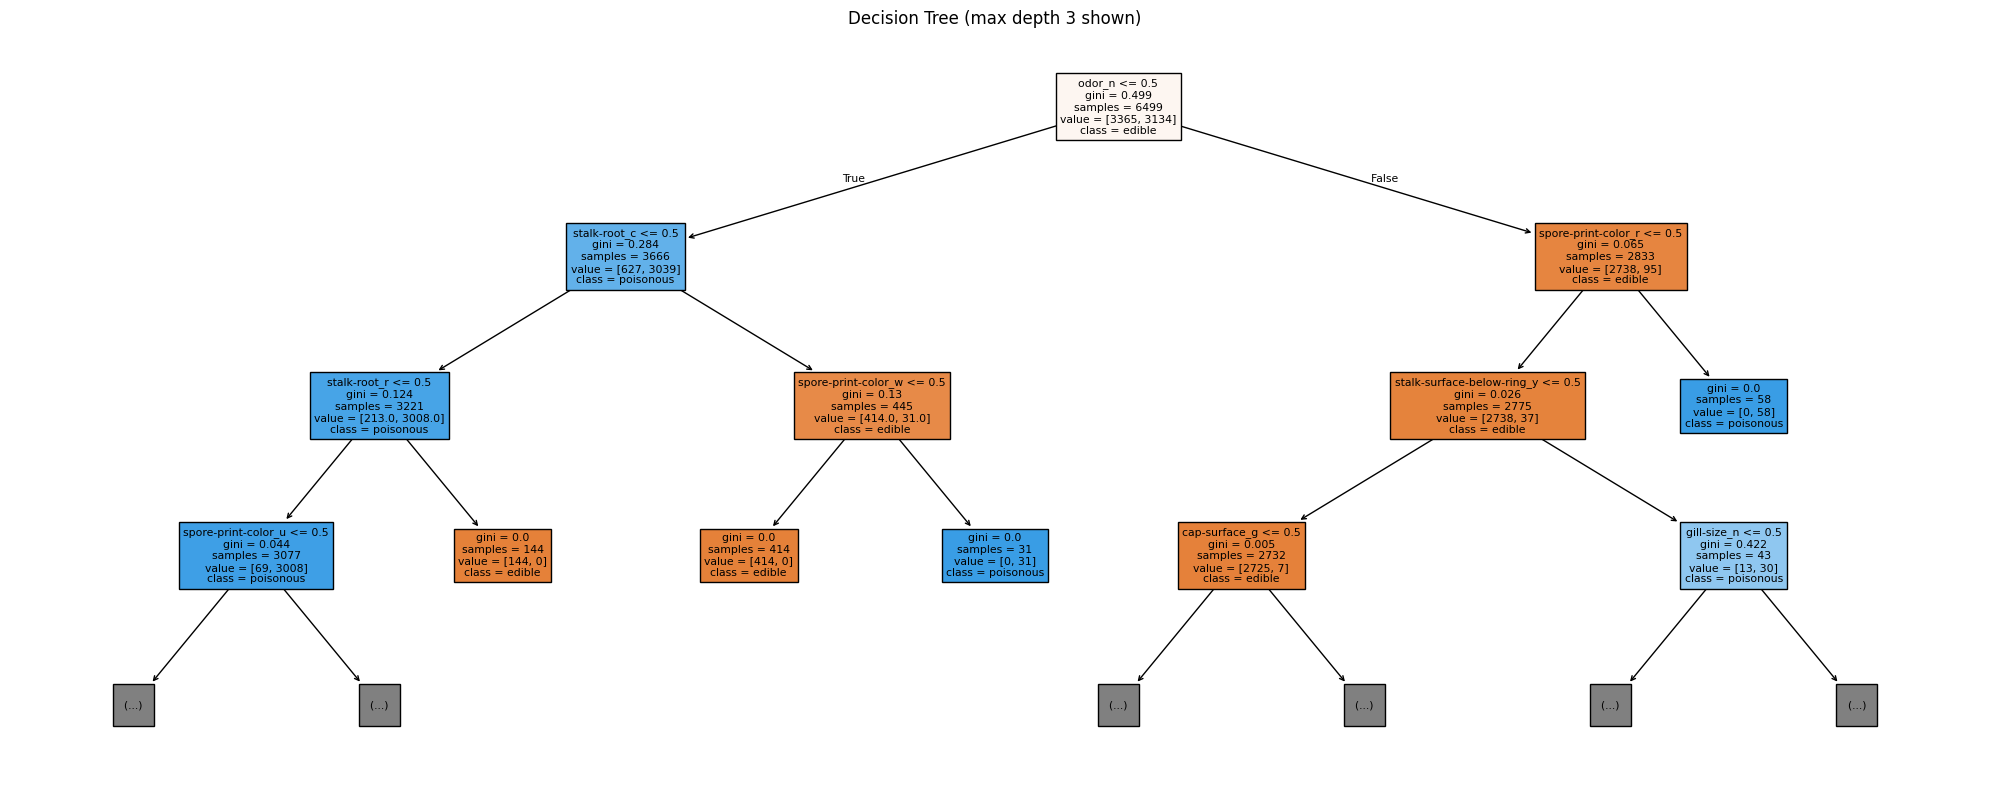

In [43]:
# visualize the decision tree
# max_depth=3 keeps the visualization readable
fig, ax = plt.subplots(figsize=(20, 8))
tree.plot_tree(dt, 
               max_depth=3,
               feature_names=X.columns,
               class_names=['edible', 'poisonous'],
               filled=True,
               ax=ax)
plt.title("Decision Tree (max depth 3 shown)")
plt.tight_layout()
plt.show()

#### 7) Use a χ2-statistic selector to pick the five best features for this data.

In [44]:
# chi2 selector - fit on training data only to prevent data leakage
selector = SelectKBest(chi2, k=5)
X_train_k = selector.fit_transform(X_train, y_train)

# transform only on test
X_test_k = selector.transform(X_test)

#### 8) Which five features were selected in step 7?

In [45]:
# use get_support() to find which features were selected
selected_features = X.columns[selector.get_support()].tolist()
print("Selected features:", selected_features)

Selected features: ['odor_f', 'odor_n', 'gill-size_n', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k']


The five selected features were: `odor_f`, `odor_n`, `gill-size_n`, `stalk-surface-above-ring_k`, and `stalk-surface-below-ring_k`. Odor features dominate, which makes intuitive sense, smell is a primary indicator of mushroom edibility.

#### 9) Repeat steps 4 and 5 with the five best features selected in step 7.

In [46]:
# fit a new decision tree using only the 5 best features
dt_k = DecisionTreeClassifier(random_state=42)
dt_k.fit(X_train_k, y_train)

y_pred_k = dt_k.predict(X_test_k)

# accuracy and confusion matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred_k):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_k))

Accuracy: 0.9735

Confusion Matrix:
[[816  27]
 [ 16 766]]


#### 10) Summarize your findings.

The full decision tree using all features achieved perfect accuracy (1.0) on the test set, correctly classifying all 1,625 mushrooms as edible or poisonous with zero errors.

The χ2 selector identified the five most statistically significant features: `odor_f`, `odor_n`, `gill-size_n`, `stalk-surface-above-ring_k`, and `stalk-surface-below-ring_k`. 

A human-based observation is that dominance of odor features aligns with real-world knowledge; odor is one of the most reliable indicators of mushroom toxicity. This is most likely the reason odor is two of the five most statistically significant features.

The reduced 5-feature model achieved an accuracy of 0.9735, misclassifying 43 out of 1,625 mushrooms (27 edible predicted poisonous, 16 poisonous predicted edible). While a 2.6% drop in accuracy seems small, in this context the 16 false negatives, poisonous mushrooms classified as edible, represent a meaningful risk.

Overall, the full feature model is clearly preferable here given the safety-critical nature of the classification task. The feature selection exercise does however confirm that a small subset of features carries most of the predictive signal in this dataset.